In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Bank_churn.csv')

In [3]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.9,1
1,15647311,Hill,608,Spain,Female,41,1,83807.9,1,0,1,112542.6,0
2,15619304,Onio,502,France,Female,42,8,159660.8,3,1,0,113931.6,1
3,15701354,Boni,699,France,Female,39,1,0.0,2,0,0,93826.6,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.8,1,1,1,79084.1,0


In [6]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.892540,1.530200,0.70550,0.515100,100090.244820,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.407418,0.581654,0.45584,0.499797,57510.493295,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.600000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.125000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.550000,1.000000,1.00000,1.000000,100193.900000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.200000,2.000000,1.00000,1.000000,149388.225000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.100000,4.000000,1.00000,1.000000,199992.500000,1.000000


# missing values

In [5]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

# charts

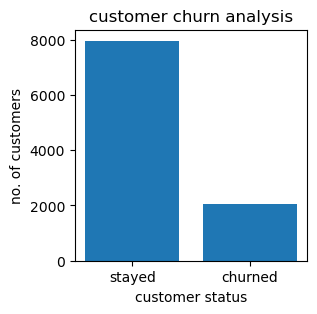

In [12]:
churn_counts=df['Exited'].value_counts()
plt.figure(figsize=(3,3))
plt.bar(['stayed','churned'],churn_counts)
plt.title('customer churn analysis')
plt.xlabel('customer status')
plt.ylabel('no. of customers')
plt.show()

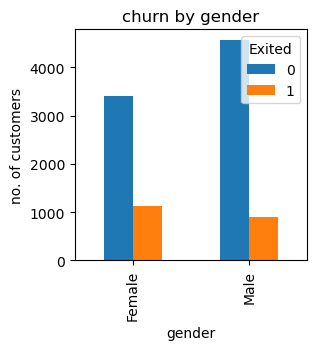

In [13]:
gender_churn=pd.crosstab(df['Gender'],df['Exited'])
gender_churn.plot(kind='bar',figsize=(3,3))
plt.title('churn by gender')
plt.xlabel('gender')
plt.ylabel('no. of customers')
plt.show()

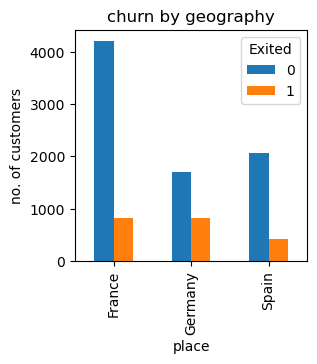

In [14]:
geo_churn=pd.crosstab(df['Geography'],df['Exited'])
geo_churn.plot(kind='bar',figsize=(3,3))
plt.title('churn by geography')
plt.xlabel('place')
plt.ylabel('no. of customers')
plt.show()

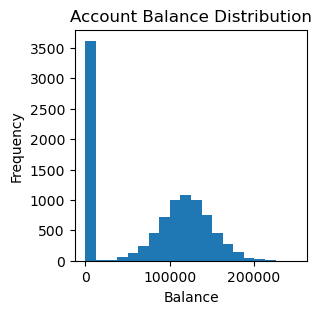

In [15]:
plt.figure(figsize=(3,3))

plt.hist(df['Balance'], bins=20)

plt.title('Account Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')

plt.show()

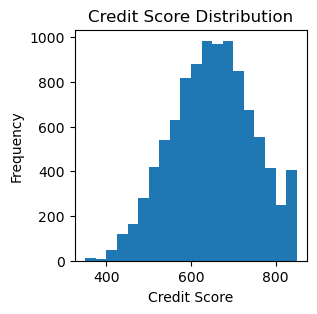

In [16]:
plt.figure(figsize=(3,3))

plt.hist(df['CreditScore'], bins=20)

plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

plt.show()

# advance analysis

In [17]:
df['Age_groups']=pd.cut(df['Age'],bins=[18,30,40,50,60,100],labels=['18-30','31-40','41-50','51-60','60+'])

In [18]:
df.sample(5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_groups
6792,15776096,Halpern,606,Spain,Male,34,3,161572.2,1,0,1,191076.2,0,31-40
5968,15603743,Tai,526,France,Male,28,1,112070.4,1,0,1,126281.8,0,18-30
2120,15651554,Anenechukwu,618,Germany,Female,54,4,118449.2,1,1,1,133573.3,1,51-60
5086,15667289,Henderson,719,Spain,Male,50,2,0.0,2,0,0,10772.1,0,41-50
2724,15812628,Dodd,453,Germany,Female,38,8,120623.2,1,1,0,129698.0,0,31-40


In [19]:
age_churn=pd.crosstab(df['Exited'],df['Age_groups'],normalize='index')*100
age_churn

Age_groups,18-30,31-40,41-50,51-60,60+
Exited,,,,,
0,22.661463,49.263502,19.287423,4.393806,4.393806
1,7.174447,26.437346,38.722359,22.014742,5.651106


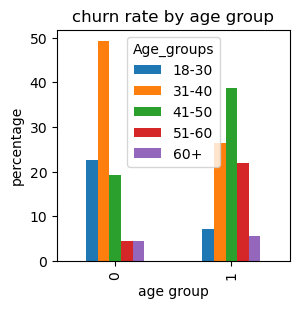

In [20]:
age_churn.plot(kind='bar',figsize=(3,3))
plt.title('churn rate by age group')
plt.xlabel('age group')
plt.ylabel('percentage')

plt.show()

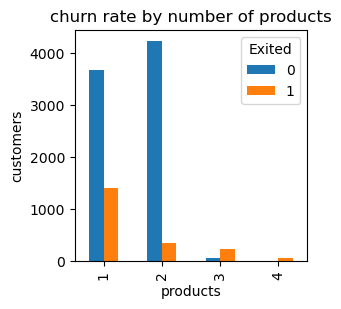

In [21]:
product_churn=pd.crosstab(df['NumOfProducts'],df['Exited'])
product_churn.plot(kind='bar',figsize=(3,3))
plt.title('churn rate by number of products')
plt.xlabel('products')
plt.ylabel('customers')

plt.show()

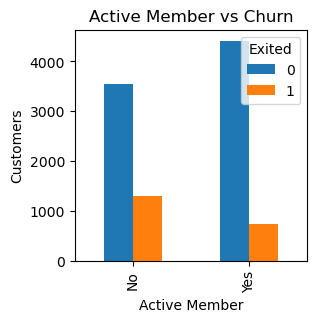

In [24]:
active_churn = pd.crosstab(df['IsActiveMember'], df['Exited'])

active_churn.plot(kind='bar', figsize=(3,3))

plt.title("Active Member vs Churn")
plt.xlabel("Active Member")
plt.ylabel("Customers")

plt.xticks([0,1],['No','Yes'])

plt.show()

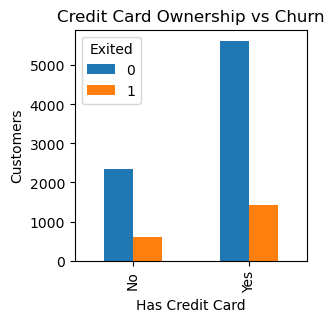

In [25]:
card_churn = pd.crosstab(df['HasCrCard'], df['Exited'])

card_churn.plot(kind='bar', figsize=(3,3))

plt.title("Credit Card Ownership vs Churn")
plt.xlabel("Has Credit Card")
plt.ylabel("Customers")

plt.xticks([0,1],['No','Yes'])

plt.show()

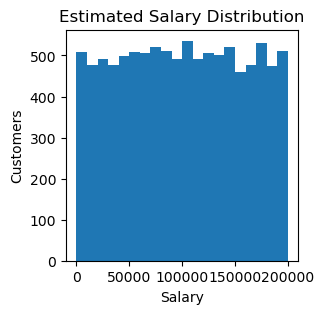

In [26]:
plt.figure(figsize=(3,3))

plt.hist(df['EstimatedSalary'], bins=20)

plt.title("Estimated Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Customers")

plt.show()

In [27]:
numeric_df=df.select_dtypes(include='number')
correlation=numeric_df.corr()
correlation

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000
